# Lab: Logistic Regression with scikit-learn

In this lab you'll learn how to fit a **Logistic Regression** model for **binary classification** using scikit-learn.

You already know the theory behind the sigmoid function and how logistic regression maps a linear combination of features to a probability. Here we focus on the **scikit-learn API** and on what makes logistic regression different from linear regression at the code level:

1. **Feature scaling** — logistic regression converges faster (and more reliably) when features are on a comparable scale.
2. **The same 3-step sklearn pattern** — `instantiate → fit → inspect`.
3. **`predict_proba()`** — unlike linear regression, we can ask the model for class *probabilities*, not just hard predictions.

We'll use the classic **Iris** dataset and frame it as a binary problem: *Is this flower an Iris-virginica?*

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Plotting configuration
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

## 2. Load & Prepare the Data

We load the Iris dataset directly from scikit-learn and build a clean DataFrame with renamed columns.

In [2]:
# Load the Iris dataset from sklearn
raw_data = datasets.load_iris()

# Build a tidy DataFrame
iris_df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
iris_df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
iris_df["class_name"] = raw_data.target_names[raw_data.target]

# Create the binary target: 1 = virginica, 0 = anything else
iris_df["is_virginica"] = (iris_df["class_name"] == "virginica").astype(int)

iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,class_name,is_virginica
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [3]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class_name    150 non-null    object 
 5   is_virginica  150 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## 3. Visualize the Data

A quick look at how the four features separate the two classes gives intuition about what the model will learn.

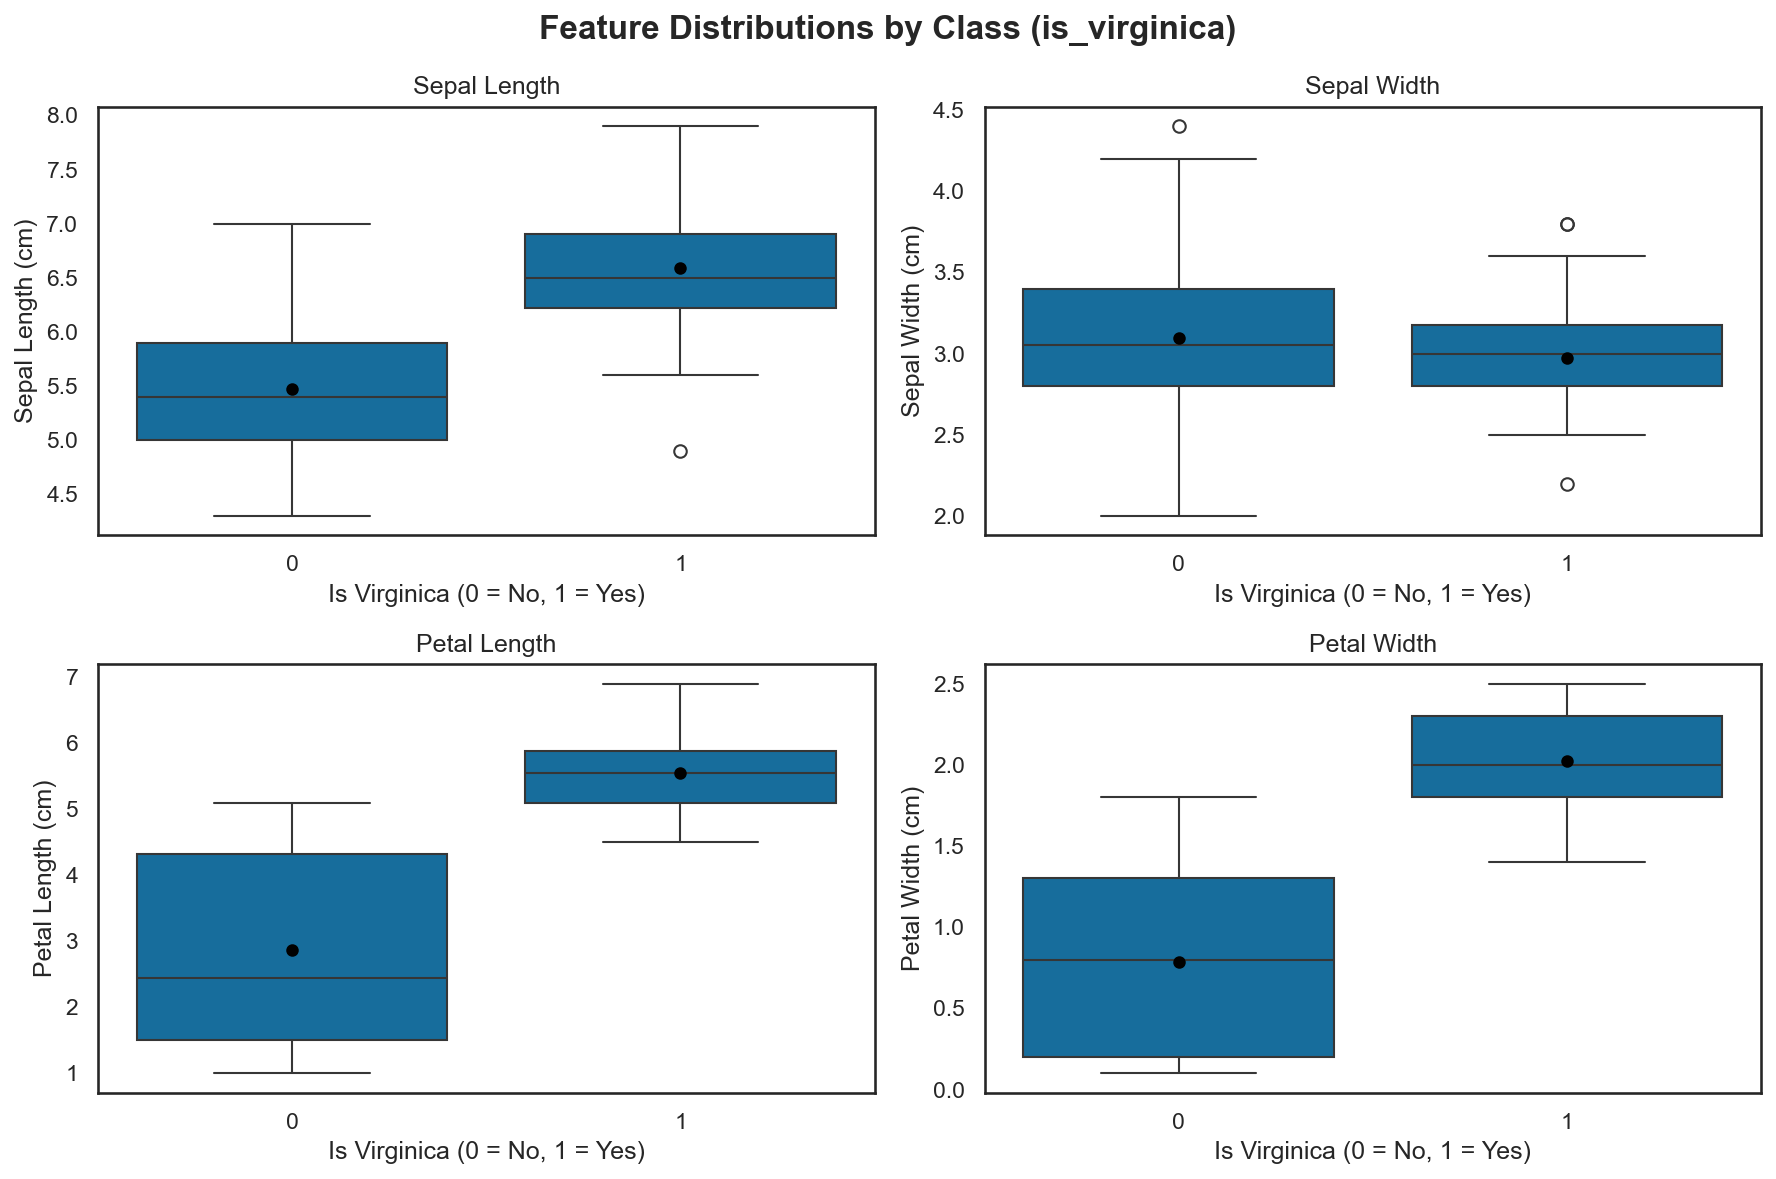

In [4]:
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Feature Distributions by Class (is_virginica)",
             fontsize=16, fontweight="bold")

for ax, feature in zip(axes.flatten(), feature_cols):
    sns.boxplot(
        data=iris_df, x="is_virginica", y=feature,
        ax=ax, showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "black",
                   "markeredgecolor": "black", "markersize": 5}
    )
    ax.set_xlabel("Is Virginica (0 = No, 1 = Yes)")
    ax.set_ylabel(feature.replace("_", " ").title() + " (cm)")
    ax.set_title(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

**Observations:**
- **Petal length** and **petal width** show very clear separation between the two classes — the model will likely lean on these features heavily.
- **Sepal** measurements overlap more, but still carry signal.

---

## 4. Feature Scaling

Logistic regression uses gradient-based optimization. When features are on very different scales, the optimizer takes longer to converge. **StandardScaler** transforms each feature to have mean = 0 and standard deviation = 1.

> **Key concept:** We fit the scaler *only* on the data we are training on, then use `transform()` to apply the same scaling everywhere. This prevents information about the test set from leaking into the training process — a topic you'll explore in depth in the *Evaluating & Validating* pillar.

In [5]:
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

X = iris_df[feature_cols]
y = iris_df["is_virginica"]

# Fit the scaler on the full dataset and transform
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Wrap the scaled array back in a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("Before scaling — mean and std of each feature:")
print(X.describe().loc[["mean", "std"]].round(2))
print()
print("After scaling — mean and std of each feature:")
print(X_scaled_df.describe().loc[["mean", "std"]].round(2))

Before scaling — mean and std of each feature:
      sepal_length  sepal_width  petal_length  petal_width
mean          5.84         3.06          3.76         1.20
std           0.83         0.44          1.77         0.76

After scaling — mean and std of each feature:
      sepal_length  sepal_width  petal_length  petal_width
mean          -0.0         -0.0          -0.0         -0.0
std            1.0          1.0           1.0          1.0


## 5. Fit the Model with scikit-learn

The same three-step sklearn pattern you've seen before:

In [6]:
# Step 1: Instantiate the model
model = LogisticRegression()

# Step 2: Fit the model to the (scaled) full dataset
model.fit(X_scaled, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 6. Inspect the Learned Parameters

Just like `LinearRegression`, the fitted `LogisticRegression` model exposes an **intercept** and **coefficients**.

The difference: these are the weights of the **log-odds** (logit) equation, not a direct prediction.  
A positive coefficient means that increasing that feature *raises* the probability of class 1 (virginica).  
A negative coefficient means the opposite.

In [7]:
print(f"Intercept (β₀): {model.intercept_[0]:.4f}")
print()

for feature, coef in zip(feature_cols, model.coef_[0]):
    direction = "↑ raises" if coef > 0 else "↓ lowers"
    print(f"  {feature:<16}  coef = {coef:+.4f}   →  {direction} P(virginica)")

Intercept (β₀): -3.8019

  sepal_length      coef = +0.1402   →  ↑ raises P(virginica)
  sepal_width       coef = -0.5146   →  ↓ lowers P(virginica)
  petal_length      coef = +2.4807   →  ↑ raises P(virginica)
  petal_width       coef = +3.1407   →  ↑ raises P(virginica)


## 7. Make Predictions

### 7a. Hard class predictions — `predict()`

`predict()` applies the default 0.5 probability threshold and returns `0` or `1` for each sample.

In [8]:
y_pred = model.predict(X_scaled)

# Show the first 10 predictions alongside the true labels
comparison = pd.DataFrame({"true": y, "predicted": y_pred}).head(10)
print(comparison.to_string(index=True))

   true  predicted
0     0          0
1     0          0
2     0          0
3     0          0
4     0          0
5     0          0
6     0          0
7     0          0
8     0          0
9     0          0


### 7b. Probability predictions — `predict_proba()`

This is what makes classifiers richer than regressors: you can ask *how confident* the model is.  
`predict_proba()` returns two columns — `P(class=0)` and `P(class=1)`. They always sum to 1.

In [9]:
y_proba = model.predict_proba(X_scaled)

# Show the first 10 rows
proba_df = pd.DataFrame(
    y_proba,
    columns=["P(not virginica)", "P(virginica)"]
).head(10).round(3)

proba_df["true_label"] = y.values[:10]
print(proba_df.to_string(index=True))

   P(not virginica)  P(virginica)  true_label
0               1.0           0.0           0
1               1.0           0.0           0
2               1.0           0.0           0
3               1.0           0.0           0
4               1.0           0.0           0
5               1.0           0.0           0
6               1.0           0.0           0
7               1.0           0.0           0
8               1.0           0.0           0
9               1.0           0.0           0


### 7c. Predict on new, unseen flowers

We must scale new inputs with the **same scaler** (already fitted), not re-fit it.

In [10]:
# Three hypothetical flowers: [sepal_length, sepal_width, petal_length, petal_width]
new_flowers = pd.DataFrame({
    "sepal_length": [6.3, 5.1, 7.2],
    "sepal_width":  [3.3, 3.5, 3.0],
    "petal_length": [6.0, 1.4, 5.8],
    "petal_width":  [2.5, 0.2, 1.6]
})

# Scale using the already-fitted scaler
new_flowers_scaled = scaler.transform(new_flowers)

predictions  = model.predict(new_flowers_scaled)
probabilities = model.predict_proba(new_flowers_scaled)

new_flowers["predicted_class"]    = predictions
new_flowers["P(virginica)"]       = probabilities[:, 1].round(3)

print(new_flowers.to_string(index=False))

 sepal_length  sepal_width  petal_length  petal_width  predicted_class  P(virginica)
          6.3          3.3           6.0          2.5                1         0.989
          5.1          3.5           1.4          0.2                0         0.000
          7.2          3.0           5.8          1.6                1         0.737


## 8. Summary

Here's what you learned in this lab compared to what you already knew from linear regression:

| | Linear Regression | Logistic Regression |
|---|---|---|
| **Task** | Predict a continuous value | Predict a class (0 or 1) |
| **Output of `predict()`** | Continuous number | Class label (0 or 1) |
| **Extra method** | — | `predict_proba()` → probability per class |
| **Parameters** | `intercept_`, `coef_` | `intercept_`, `coef_` (same!) |
| **Coefficient meaning** | Change in target per unit feature | Change in **log-odds** per unit feature |
| **Feature scaling** | Not required (but helpful) | Recommended for faster convergence |
| **sklearn pattern** | `instantiate → fit → inspect` | `instantiate → fit → inspect` (same!) |

The key new concept is **`StandardScaler`**: fit it once on your training data, then use `transform()` everywhere else.

---

**Next:** [Decision Trees Theory](./11_decision_trees_theory.md)